In [11]:
#!pip install torch torchvision matplotlib
#!pip install torchvision

In [1]:
import torch
import torchvision.transforms as T
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

In [2]:
url = "https://images.pexels.com/photos/145939/pexels-photo-145939.jpeg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

In [3]:
# Resize & transform to tensor
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor()
])
img_tensor = transform(img)

In [4]:
# Show original image
def show_image(tensor, title=""):
    img = tensor.permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

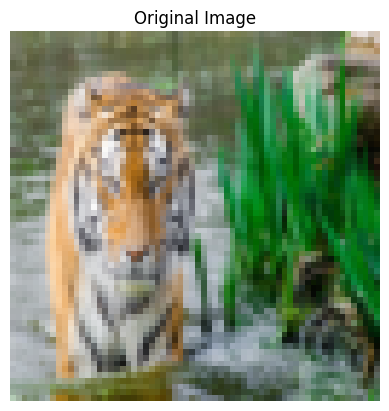

In [5]:
show_image(img_tensor, title="Original Image")

In [6]:
# Noising function
def add_noise(x, noise_level):
    noise = torch.randn_like(x) * noise_level
    return x + noise

# Simulate progressive noising
timesteps = [0.1, 0.3, 0.5, 1.0]  # different levels of Gaussian noise
noised_images = [add_noise(img_tensor, t) for t in timesteps]


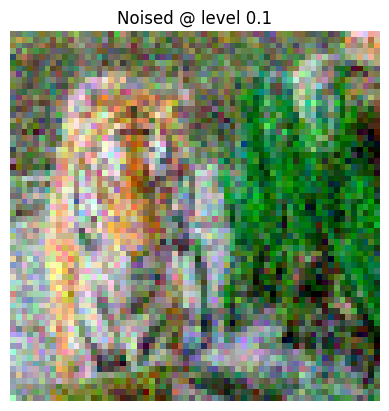

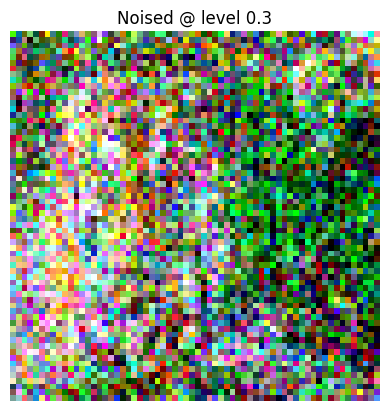

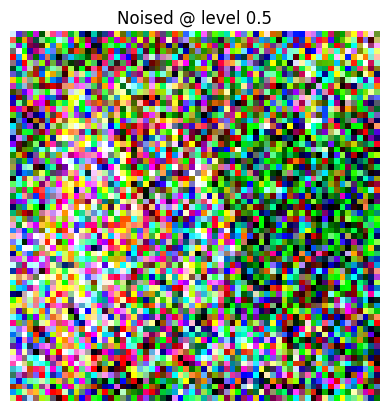

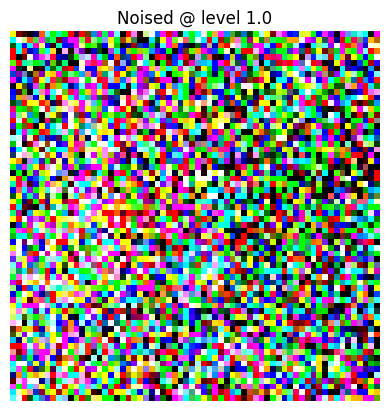

In [7]:
# Show noised images
for i, (t, img) in enumerate(zip(timesteps, noised_images)):
    show_image(torch.clamp(img, 0, 1), title=f"Noised @ level {t}")

In [8]:
# Simulate dummy denoising (not learned — just for illustration)
def denoise(x, noise_level):
    return torch.clamp(x - (torch.randn_like(x) * noise_level * 0.8), 0, 1)

# Simulate reverse steps
denoised_images = []
current = noised_images[-1]
for step in [0.5, 0.3, 0.1]:
    current = denoise(current, step)
    denoised_images.append(current)


In [ ]:
# Show denoised steps
for i, img in enumerate(denoised_images):
    show_image(img, title=f"Denoised Step {i+1}")

In [12]:
#Generating image using pre-trained model (diffusers)
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

In [14]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [15]:
# Prompt to generate a tiger
prompt = "A majestic tiger standing in a jungle, photorealistic"

In [ ]:
image = pipe(prompt).images[0]
image.show()

  0%|          | 0/50 [00:00<?, ?it/s]